<a href="https://colab.research.google.com/github/JustUty/Parsing-and-analyzing-all-news/blob/main/My_course.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
import pymorphy2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.metrics import MeanSquaredError, MeanAbsoluteError, RootMeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from keras.regularizers import l2

In [ ]:
token = '***********************************api_ver = '5.199'
ids = ['aviation__is__our__life', 'poezda_umchatsia_k_moriu', 'riverfleet', 'rusautomobile'] # ссылки на группы
posts_count = 100
data = pd.DataFrame(columns=['post_text', 'likes_count', 'comments_count', 'owner_id']) # здесь будут храниться текст поста, его лайки, кол-во коментов, и откуда взят

session = vk_api.VkApi(token=token)
api = session.get_api()

for id in ids:
    for offset in range(0, 5000, 100):
        wall_posts = api.wall.get(owner_id=id, count=posts_count, v=api_ver, offset=offset)['items']
        for post in wall_posts:
            if len(post['text']) == 0:
              pass
            post_text = post['text']
            likes_count = post['likes']['count']
            comments_count = post['comments']['count']
            if 'copy_history' in post and len(post['copy_history']) > 0:
                post_text = post['copy_history'][0]['text']
            data.loc[len(data.index)] = [post_text, likes_count, comments_count, id]

excel_filename = 'parser_fin.xlsx'

# Сохраняем DataFrame в файл Excel
data.to_excel(excel_filename, index=False)

print(len(data))

10430

In [ ]:
# Загрузка данных
file_path = 'parser_fin.xlsx'
df = pd.read_excel(file_path)

print(df['comments_count'].info())
print(df['post_text'].info())

<class 'pandas.core.series.Series'>
RangeIndex: 10430 entries, 0 to 10429
Series name: comments_count
Non-Null Count  Dtype
--------------  -----
10430 non-null  int64
dtypes: int64(1)
memory usage: 81.6 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 10430 entries, 0 to 10429
Series name: post_text
Non-Null Count  Dtype 
--------------  ----- 
9459 non-null   object
dtypes: object(1)
memory usage: 81.6+ KB
None


In [ ]:
df.head()

,post_text,likes_count,comments_count,owner_id
0,Второй ✈ Airbus A350-900 для авиакомпании 🇦🇪 E...,188,9,aviation__is__our__life
1,Первый полет первого ✈ Airbus A321neo для неме...,103,4,aviation__is__our__life
2,Шестой ✈ COMAC C919 🇨🇳 China Eastern Airlines....,125,36,aviation__is__our__life
3,Американский оборонный подрядчик Sierra Nevada...,56,13,aviation__is__our__life
4,🇸🇦🇪🇺 Saudia Group заказала 105 самолётов у Air...,78,22,aviation__is__our__life


In [ ]:
df = df[~df['post_text'].isna() & (df['post_text'] != 'Post deleted')]

len(df)
df.head()

,post_text,likes_count,comments_count,owner_id
0,Второй ✈ Airbus A350-900 для авиакомпании 🇦🇪 E...,188,9,aviation__is__our__life
1,Первый полет первого ✈ Airbus A321neo для неме...,103,4,aviation__is__our__life
2,Шестой ✈ COMAC C919 🇨🇳 China Eastern Airlines....,125,36,aviation__is__our__life
3,Американский оборонный подрядчик Sierra Nevada...,56,13,aviation__is__our__life
4,🇸🇦🇪🇺 Saudia Group заказала 105 самолётов у Air...,78,22,aviation__is__our__life


In [ ]:
# Удаление смайлов

def remove_emojis(text):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"
                               u"\U0001F300-\U0001F5FF"
                               u"\U0001F680-\U0001F6FF"
                               u"\U0001F1E0-\U0001F1FF"
                               u"\U00002500-\U00002BEF"
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

df['post_text'] = df['post_text'].apply(remove_emojis)
df.head(5)

,post_text,likes_count,comments_count,owner_id
0,Второй Airbus A350-900 для авиакомпании Emir...,188,9,aviation__is__our__life
1,Первый полет первого Airbus A321neo для немец...,103,4,aviation__is__our__life
2,Шестой COMAC C919 China Eastern Airlines. Эт...,125,36,aviation__is__our__life
3,Американский оборонный подрядчик Sierra Nevada...,56,13,aviation__is__our__life
4,Saudia Group заказала 105 самолётов у Airbus\...,78,22,aviation__is__our__life


In [ ]:
def clean_text(text):
    text = re.sub(r'\s+', ' ', text) # \n -> ' '
    text = text.lower()
    text = re.sub(r'-', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^а-яёa-z0-9 ]', '', text)
    return text

df['post_text'] = df['post_text'].apply(clean_text)

df.head(5)

,post_text,likes_count,comments_count,owner_id
0,второй airbus a350 900 для авиакомпании emirat...,188,9,aviation__is__our__life
1,первый полет первого airbus a321neo для немецк...,103,4,aviation__is__our__life
2,шестой comac c919 china eastern airlines это п...,125,36,aviation__is__our__life
3,американский оборонный подрядчик sierra nevada...,56,13,aviation__is__our__life
4,saudia group заказала 105 самолётов у airbus ...,78,22,aviation__is__our__life


In [ ]:
nltk.download('stopwords')
ru_stopwords = set(stopwords.words('russian'))

def del_words(text):
    tokens = text.split()
    tokens = [token for token in tokens if token not in ru_stopwords]
    return ' '.join(tokens)

df['post_text'] = df['post_text'].apply(del_words)

df.head(5)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\79006\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,post_text,likes_count,comments_count,owner_id
0,второй airbus a350 900 авиакомпании emirates п...,188,9,aviation__is__our__life
1,первый полет первого airbus a321neo немецкой а...,103,4,aviation__is__our__life
2,шестой comac c919 china eastern airlines это п...,125,36,aviation__is__our__life
3,американский оборонный подрядчик sierra nevada...,56,13,aviation__is__our__life
4,saudia group заказала 105 самолётов airbus сде...,78,22,aviation__is__our__life


In [ ]:
morph = pymorphy2.MorphAnalyzer()

# Токенизация + лемматизация
def tokenize_and_lemmatize(text):
    tokens = word_tokenize(text)
    lemmatized_tokens = [morph.parse(token)[0].normal_form for token in tokens]
    return lemmatized_tokens

df['post_text'] = df['post_text'].apply(tokenize_and_lemmatize)

df.head(5)

,post_text,likes_count,comments_count,owner_id
0,"[второй, airbus, a350, 900, авиакомпания, emir...",188,9,aviation__is__our__life
1,"[первый, полёт, первый, airbus, a321neo, немец...",103,4,aviation__is__our__life
2,"[шестой, comac, c919, china, eastern, airlines...",125,36,aviation__is__our__life
3,"[американский, оборонный, подрядчик, sierra, n...",56,13,aviation__is__our__life
4,"[saudia, group, заказать, 105, самолёт, airbus...",78,22,aviation__is__our__life


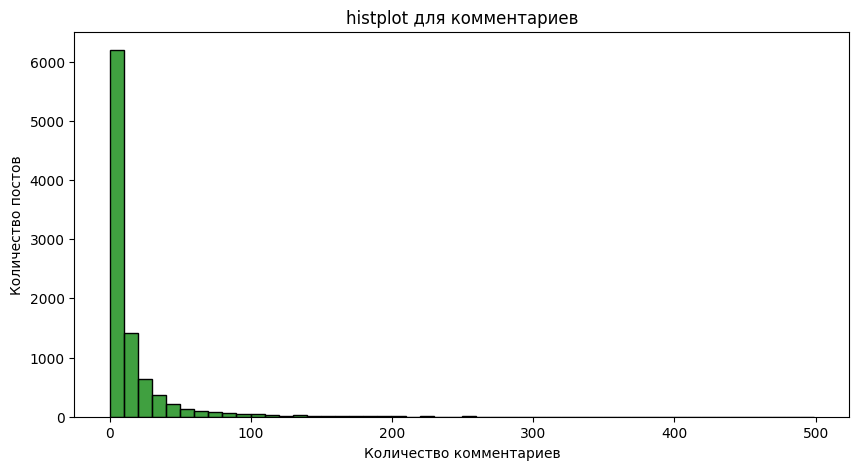

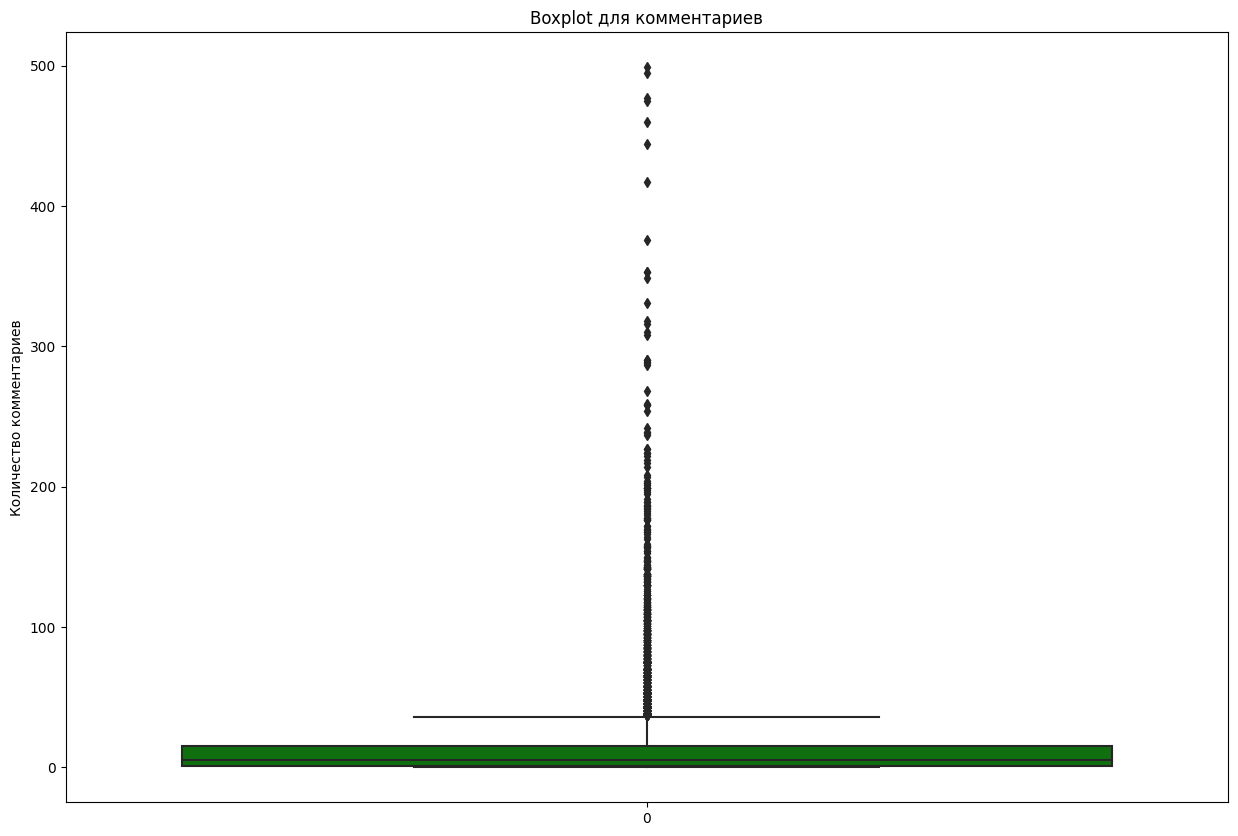

Count: 9459
Std: 30.909525289169153
Mean: 14.623956020721007


In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['comments_count'], kde=False, bins=50, color='green')
plt.title('histplot для комментариев')
plt.xlabel('Количество комментариев')
plt.ylabel('Количество постов')
plt.show()

plt.figure(figsize=(15, 10))
sns.boxplot(df['comments_count'], color='green')
plt.title('Boxplot для комментариев')
plt.ylabel('Количество комментариев')
plt.show()

print('Count:', df['comments_count'].count())
print('Std:', df['comments_count'].std())
print('Mean:', df['comments_count'].mean())

In [ ]:
drop_noiseMC = df[df['comments_count'] > 100].index

df = df.drop(drop_noiseMC)
print(len(df))

9247


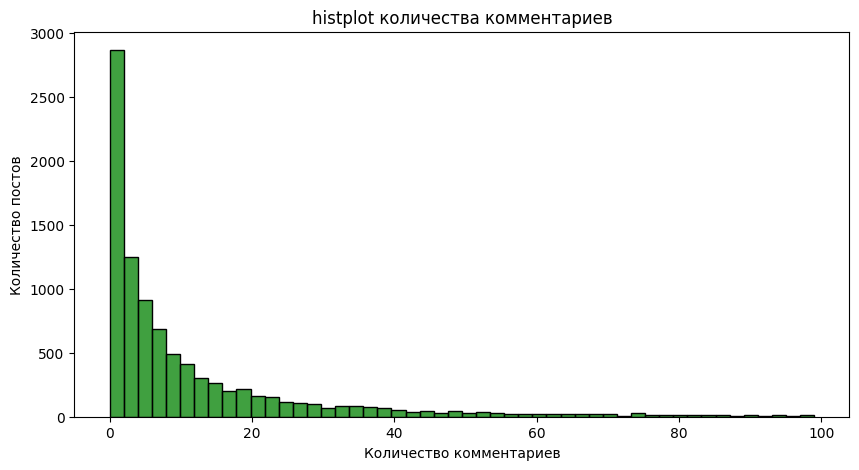

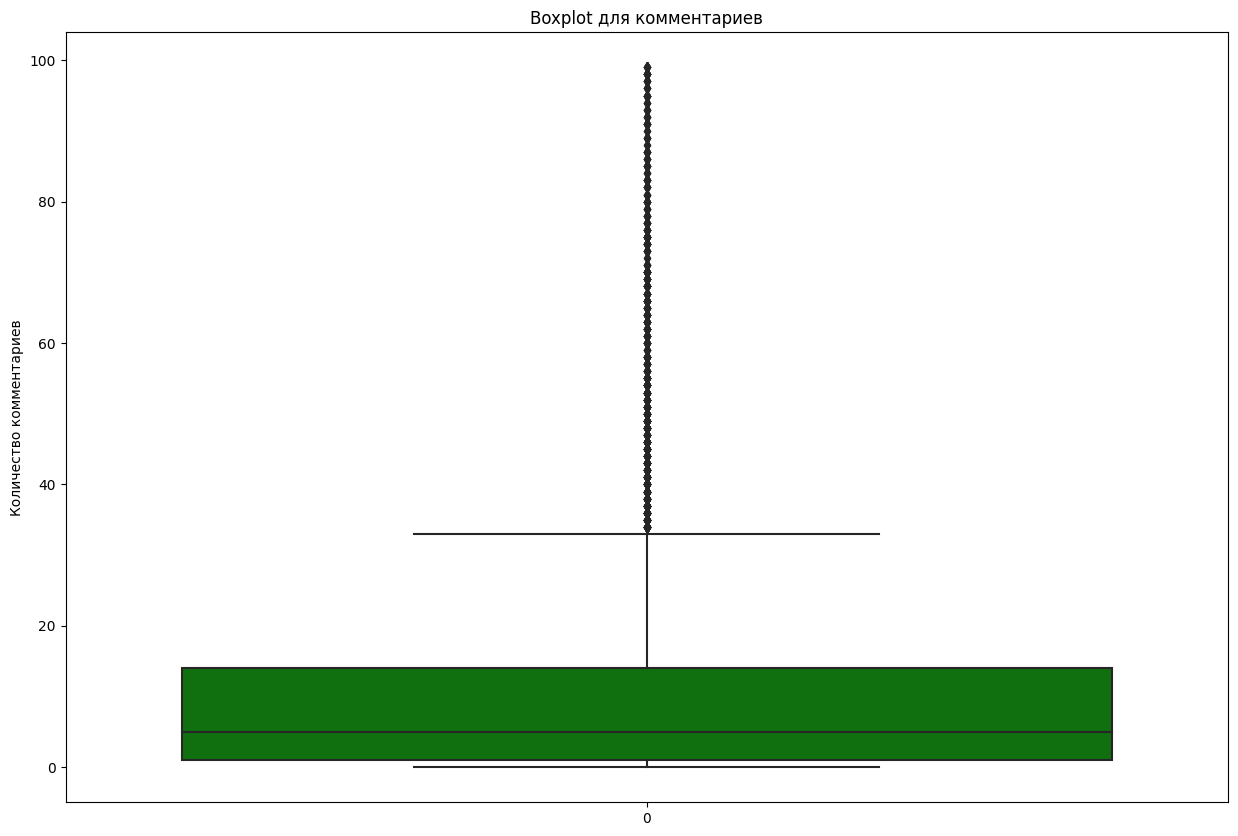

Count: 9247
Std: 16.74909779301408
Mean: 11.11928192927436


In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['comments_count'], kde=False, bins=50, color='green')
plt.title('histplot количества комментариев')
plt.xlabel('Количество комментариев')
plt.ylabel('Количество постов')
plt.show()

plt.figure(figsize=(15, 10))
sns.boxplot(df['comments_count'], color='green')
plt.title('Boxplot для комментариев')
plt.ylabel('Количество комментариев')
plt.show()

print('Count:', df['comments_count'].count())
print('Std:', df['comments_count'].std())
print('Mean:', df['comments_count'].mean())

In [ ]:
y_log = np.log1p(df['comments_count'])

mask_zero_likes = df['comments_count'] == 0
data_balanced = pd.concat([df[~mask_zero_likes], df[mask_zero_likes].sample(frac=0.3, random_state=42)])

X_train, X_test, y_train, y_test = train_test_split(data_balanced['post_text'], y_log[data_balanced.index], test_size=0.2, random_state=42)

In [ ]:
# Инициализация токенизатора
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['post_text'])  # Обучение токенизатора на тренировочных данных

# Преобразование текстов в последовательности индексов
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Подготовка длины последовательности для всех данных
max_len = max(max(len(seq) for seq in X_train_seq), max(len(seq) for seq in X_test_seq))
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Сохранение размера словаря для использования в слое Embedding
vocab_size = len(tokenizer.word_index) + 1  # +1 для нулевого индекса, не используемого в словах

In [ ]:
df.head(5)

,post_text,likes_count,comments_count,owner_id
0,"[второй, airbus, a350, 900, авиакомпания, emir...",188,9,aviation__is__our__life
1,"[первый, полёт, первый, airbus, a321neo, немец...",103,4,aviation__is__our__life
2,"[шестой, comac, c919, china, eastern, airlines...",125,36,aviation__is__our__life
3,"[американский, оборонный, подрядчик, sierra, n...",56,13,aviation__is__our__life
4,"[saudia, group, заказать, 105, самолёт, airbus...",78,22,aviation__is__our__life


In [ ]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=100, input_length=max_len))
model.add(LSTM(32, return_sequences=True, kernel_regularizer=l2(0.01)))
model.add(Dropout(0.3))
model.add(BatchNormalization())
model.add(Dense(1, activation='linear'))

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mean_squared_error', 'mean_absolute_error', RootMeanSquaredError()])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history2 = model.fit(X_train_pad, y_train, epochs=25, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

C:\Users\79006\AppData\Roaming\Python\Python310\site-packages\keras\src\engine\data_adapter.py:1808: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  return t[start:end]


Epoch 1/25
79/79 [==============================] - 28s 327ms/step - loss: 4.6606 - mean_squared_error: 4.0041 - mean_absolute_error: 1.6833 - root_mean_squared_error: 2.0010 - val_loss: 2.9083 - val_mean_squared_error: 2.5690 - val_mean_absolute_error: 1.3091 - val_root_mean_squared_error: 1.6028
Epoch 2/25
79/79 [==============================] - 26s 334ms/step - loss: 1.9676 - mean_squared_error: 1.7509 - mean_absolute_error: 1.0670 - root_mean_squared_error: 1.3232 - val_loss: 1.4468 - val_mean_squared_error: 1.3101 - val_mean_absolute_error: 0.9343 - val_root_mean_squared_error: 1.1446
Epoch 3/25
79/79 [==============================] - 26s 335ms/step - loss: 1.3562 - mean_squared_error: 1.2514 - mean_absolute_error: 0.9178 - root_mean_squared_error: 1.1187 - val_loss: 1.3376 - val_mean_squared_error: 1.2561 - val_mean_absolute_error: 0.9224 - val_root_mean_squared_error: 1.1208
Epoch 4/25
79/79 [==============================] - 27s 337ms/step - loss: 1.3012 - mean_squared_error:

In [ ]:
 # Оценка модели на тестовом наборе данных
test_loss, test_mse, test_mae, test_rmse = model.evaluate(X_test_pad, y_test, verbose=1)
print(f"Test Loss: {test_loss}, Test MSE: {test_mse}, Test MAE: {test_mae}, Test RMSE: {test_rmse}")

50/50 [==============================] - 2s 44ms/step - loss: 1.3414 - mean_squared_error: 1.3255 - mean_absolute_error: 0.9507 - root_mean_squared_error: 1.1513
Test Loss: 1.341446042060852, Test MSE: 1.325536847114563, Test MAE: 0.9507356882095337, Test RMSE: 1.1513196229934692


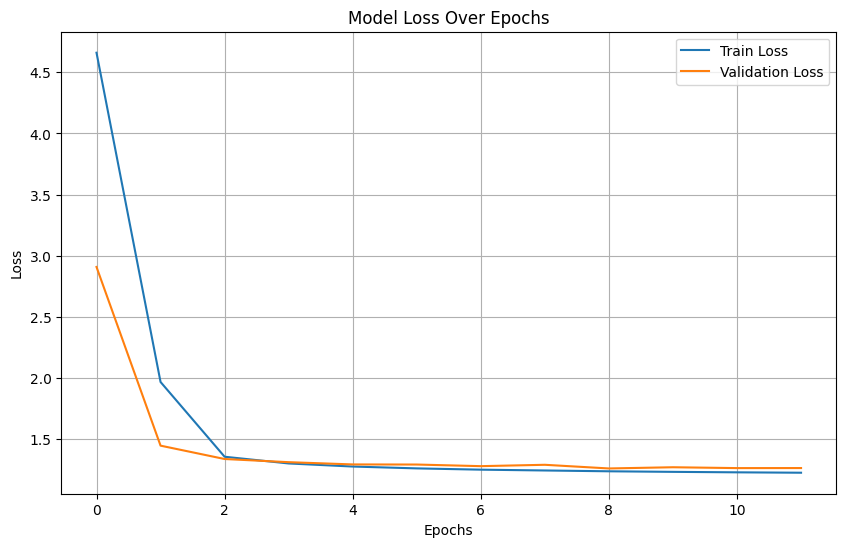

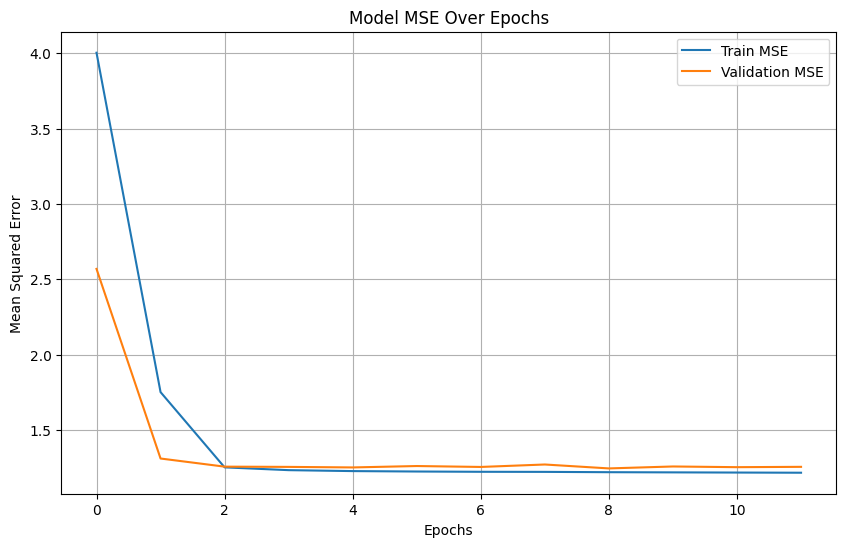

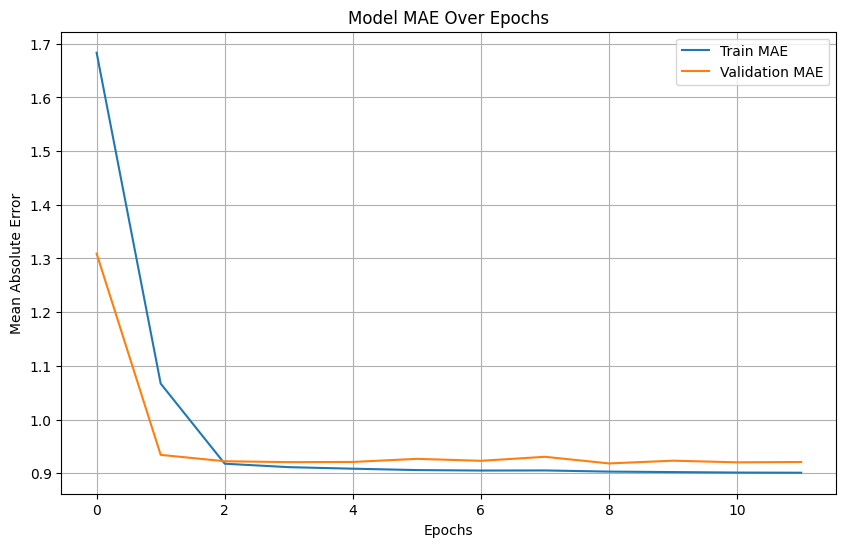

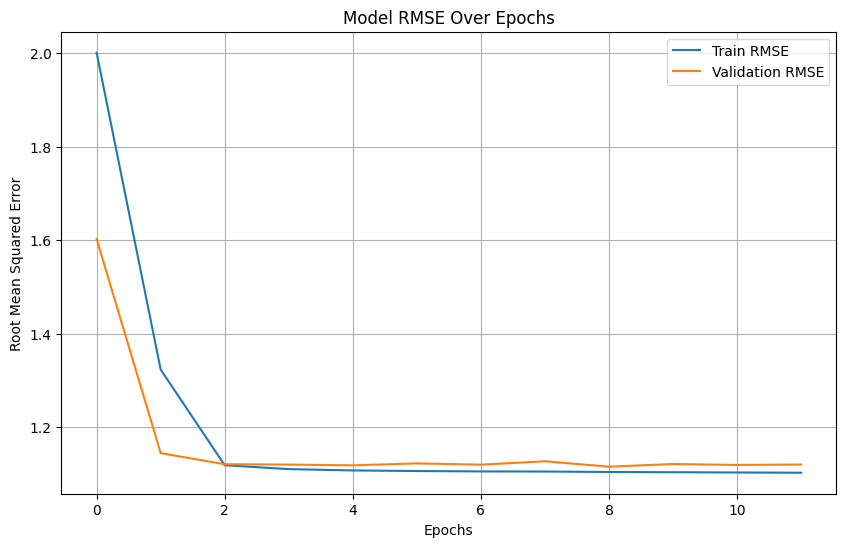

In [ ]:
# Построение графика потерь
plt.figure(figsize=(10, 6))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Построение графика MSE
plt.figure(figsize=(10, 6))
plt.plot(history2.history['mean_squared_error'], label='Train MSE')
plt.plot(history2.history['val_mean_squared_error'], label='Validation MSE')
plt.title('Model MSE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

# Построение графика MAE
plt.figure(figsize=(10, 6))
plt.plot(history2.history['mean_absolute_error'], label='Train MAE')
plt.plot(history2.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

# Построение графика RMSE
plt.figure(figsize=(10, 6))
plt.plot(history2.history['root_mean_squared_error'], label='Train RMSE')
plt.plot(history2.history['val_root_mean_squared_error'], label='Validation RMSE')
plt.title('Model RMSE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Root Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def count_comments(post_text):
    cleaned_text = clean_text(post_text)
    stop_word = del_words(cleaned_text)

    tokens = stop_word.split()
    lemmatized_tokens = lemmatize_tokens(tokens)
    lemmatized_text = ' '.join(lemmatized_tokens)

    sequence = tokenizer.texts_to_sequences([lemmatized_text])
    padded_sequence = pad_sequences(sequence, maxlen=max_len)

    predicted_log_comments = model.predict(padded_sequence)
    predicted_comments = np.exp(predicted_log_comments) - 1

    return predicted_comments[0][0]

In [ ]:
# Пример использования
post = """ ⚡В НАСТУПИВШЕМ ГОДУ ПОРТ АРХАНГЕЛЬСК ОТМЕТИТ 440-ЛЕТИЕ. ПЕРЕМЕНЫ В ЕГО РАБОТЕ УЖЕ НАЧАЛИСЬ

📌Начнем с того, что Росморречфлот, подводя итоги работы морских портов России, отметил, суммарный грузооборот портов вырос на 5 процентов и составил 884 миллиона тонн. И это несмотря на многочисленные препятствия со стороны Европейского Союза.

📌Какую роль в общем объеме переработки грузов сыграл порт Архангельск, который по многим параметрам нельзя даже сравнивать с такими гигантами, как Новороссийск или Санкт-Петербург?

📌Тем не менее, нельзя забывать, что первый порт России (а в 2024 году мы отмечаем его 440-летие) живет и работает. Подробности - в материале регионального корреспондента Флагман-ньюс.

📌За многие десятилетия в Архангельске сложились три четких направления грузопотоков: экспорт пиломатериалов и нефтепродуктов, каботажные перевозки генеральных грузов в Арктику, транспортировка лесных и строительных грузов по внутренним водным путям.

📌В 2023 году произошли значительные изменения в работе порта с экспортными грузами, и причина – запрет на заход для российского флота в порты Европы. Всего 3 – 4 года назад из Архангельска за неделю выходило по 7 – 10 судов как с пилолесом, так и с нефтепродуктами.

📌В году минувшем – только по одному-двум судам-лесовозам или танкерам в месяц. Итог 2023 года: от причалов лесозаводов Архангельска в порты Средиземноморья отправлено менее ста тысяч лесных грузов, от причала Талажской нефтебазы «Роснефть» - около 280 тысяч тонн в порты Африки и Средней Азии.

📌Грузовой район Левый берег отгрузил в порты Турции чуть больше 30 тысяч тонн металлолома, для сравнения - 2 года назад эта цифра приближалась к 150 тысячам тонн. И наконец, в прошлом году в порт Архангельск грузов из-за границы вообще не поступало.

📌Логично, что поток грузов на Арктической линии стал основным. Судоходные компании – Северное морское пароходство, «Северный проект», «Эко-шиппинг» - отправляли свои суда не только в период навигации, в суровую зиму перевозки на Север также не прекращались.

📌В рейсовых заданиях значились порты Харасавей, Сабетта, Диксон, Дудинка, Тикси, Певек. В равной степени в погрузке каботажных судов участвовали портовики грузовых районов Экономии, Соломбальского терминала, Левого берега. Общее количество переработанных генеральных грузов составило более одного миллиона тонн.

📌Архангельские нефтебазы - Талажская, поселка Глухое и Бункерной компании обеспечили топливом населенные пункты Баренцева и Белого морей, все Арктическое побережье, включая Землю Франца-Иосифа. Мазут для котельных, солярку для дизельных электростанций, бензин для автотехники. Всего из Архангельска в каботаже было отправлено около 700 тысяч тонн горюче-смазочных материалов.

📌Говоря о многотысячных объемах переработанного груза, мы редко вспоминаем тех, кто перевозит товары, запчасти для оборудования и продукты порой крохотными партиями – на Соловки, в Амдерму и на Варандей, в поморские деревни, на полярные станции Арктических морей.

📌Экипажи таких судов прибрежного плавания как «Вайново», «Антей», «Даурия», экспедиционных судов «Гидрографического предприятия и Северного управления гидрометслужбы внесли свой вклад в итог работы порта. А главное – обеспечили жителей прибрежных населенных пунктов, полярников метеостанций всем необходимым на долгую суровую зиму.

📌Поставку грузов с верховий Северной Двины архангельским лесопромышленникам и дорожным строителям в основном обеспечивали Архангельский речной порт, Северо-Двинское речное пароходство и Беломорская сплавная компания.

📌Барже-буксирные караваны и буксируемые плоты с лесом-пиловочником начали прибывать к причалам и лесостоянкам порта сразу после ледохода. Их работа не прекращалась до глубокой осени, и лишь с началом ледостава речной флот отправился к местам зимнего отстоя.

📌Также активно трудились экипажи буксиров, которые водили баржи-шаланды от грунтоперегружателя, установленного на речных отмелях, к стройплощадкам города. Общее количество грузов, доставленных по реке в Архангельск, достигло 2,4 миллиона тонн.

#путиипорты@flagmannews """

predicted_comments = count_comments(post)
print(f"Кол-во комментариев: {predicted_comments}")

NameError: name 'count_comments' is not defined

In [ ]:
# Пример использования
post = """ Уважаемые друзья! Пришло время объявить итоги конкурса на самую лучшую авторскую фотографию!

Итак барабаная дробь! ‼

И победителем становится Степан Федотов с фотографией из чистой зоны аэропорта Пулково ✈

Фотография набрала 483 лайка и более 36 тыс. просмотров 💪✈

Поздравляем Степана от все души и просим связаться с нами через ЛС группы 💪 """

predicted_comments = count_comments(post)
print(f"Кол-во комментариев: {predicted_comments}")

1/1 [==============================] - 0s 58ms/step
Кол-во комментариев: [9.322351]


In [ ]:
# Пример использования
post = """ ⚡ГОРОДЕЦКИЙ СРМЗ ЗАВЕРШАЕТ ПОДГОТОВКУ ФЛОТА К НАВИГАЦИИ - ФОТО

📌Городецкий судоремонтно-механический завод (Нижегородская область) готовится к предстоящему спуску судов и вводу флота в эксплуатацию.

📌Завершается зимний судоремонт, ведутся покрасочные работы, корпуса судов проходят испытания герметичности ДЗА.

📌 В межнавигационный период на предприятии проведены плановые ремонты корпусов судов, механизмов и систем, движительно-рулевых комплексов и других судовых элементов.

#фото@flagmannews
Фото: Валерий Новиков / Флагман-ньюс."""

predicted_comments = count_comments(post)
print(f"Кол-во комментариев:: {predicted_comments}")

1/1 [==============================] - 0s 91ms/step
Кол-во комментариев: [7.213482]
